# NB03: Feature Extraction
Extracts three feature channels for the full PromptGuard corpus:
1. Activation vectors from Llama-3.2-3B-Instruct at the optimal middle layer (identified by layer sweep)
2. Heuristic rule-based features (phrase counts, encoding flags, structural markers, imperative verb ratio, length z-score)
3. Sentence embeddings via all-mpnet-base-v2

**Artifacts produced:**
- `activation_features.npz` — shape (N_samples, 3072)
- `heuristic_features.csv` — shape (N_samples, 8 feature columns)
- `embedding_features.npz` — shape (N_samples, 768)
- `lodo_splits.json` — authoritative 15-fold LODO definitions (validated from Phase 2)
- `layer_sweep_results.json` — per-layer LODO AUC and optimal layer identification

In [1]:
!pip install transformers>=4.45 sentence-transformers -q
# torch, numpy, pandas, sklearn, matplotlib are pre-installed in Colab

In [2]:
import os, glob, json, re, unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoConfig
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from google.colab import drive
print("Imports complete.")

Imports complete.


## Section 0: Environment Setup

This section mounts Google Drive, defines all artifact path constants, asserts GPU availability, and loads the unified corpus. All subsequent sections depend on the constants defined here.

GPU availability is required for Llama-3.2-3B-Instruct activation extraction (Sections 2 and 3). The sentence embedding channel (Section 5) is CPU-compatible but runs after GPU work completes.

In [3]:
drive.mount('/content/drive')

# --- Path constants (edit DRIVE_ROOT if your Drive path differs) ---
DRIVE_ROOT          = "/content/drive/MyDrive/PromptGuard"
CORPUS_PATH         = f"{DRIVE_ROOT}/unified_corpus.csv"
LODO_SPLITS_PATH    = f"{DRIVE_ROOT}/lodo_splits.json"
LAYER_SWEEP_PATH    = f"{DRIVE_ROOT}/layer_sweep_results.json"
ACTIVATION_PATH     = f"{DRIVE_ROOT}/activation_features.npz"
HEURISTIC_PATH      = f"{DRIVE_ROOT}/heuristic_features.csv"
EMBEDDING_PATH      = f"{DRIVE_ROOT}/embedding_features.npz"
CHECKPOINT_DIR      = f"{DRIVE_ROOT}/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(DRIVE_ROOT, exist_ok=True)

# --- GPU check ---
assert torch.cuda.is_available(), "No GPU detected. Switch to GPU runtime: Runtime > Change runtime type > T4 GPU"
gpu_name = torch.cuda.get_device_name(0)
vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"GPU: {gpu_name}  |  VRAM: {vram_gb:.1f} GB")
print(f"DRIVE_ROOT: {DRIVE_ROOT}")

Mounted at /content/drive
GPU: NVIDIA A100-SXM4-40GB  |  VRAM: 42.4 GB
DRIVE_ROOT: /content/drive/MyDrive/PromptGuard


In [4]:
df = pd.read_csv(CORPUS_PATH)
df = df.reset_index(drop=True)  # CRITICAL: positional index for LODO splits
assert df.index.tolist() == list(range(len(df))), "Index is not 0-based contiguous — reset_index failed"
assert set(["text", "label", "source_dataset", "attack_type", "generation_method"]).issubset(df.columns), \
    "Missing required columns"
assert df[["text", "label", "source_dataset"]].isnull().sum().sum() == 0, "Null values in core columns"
N = len(df)
print(f"Corpus loaded: {N} samples, {df['source_dataset'].nunique()} sources, {df['label'].mean():.3f} malicious rate")
print(f"Columns: {list(df.columns)}")

Corpus loaded: 52381 samples, 15 sources, 0.663 malicious rate
Columns: ['text', 'label', 'source_dataset', 'attack_type', 'generation_method']


## Section 1: LODO Split Validation

Phase 2 (NB02, Section 2) saved `lodo_splits.json` as a preliminary artefact containing 15 LODO fold definitions — one per held-out source dataset. Phase 3 treats this file as the authoritative fold definition for all downstream phases (Phase 4 training, Phase 5 evaluation), but only after the following validation assertions pass:

1. Fold count == 15 (one per distinct source in the corpus)
2. No sample index appears in both train and test within any fold (no leakage)
3. All sample indices are valid integers in [0, N-1]
4. Per-fold train + test sizes sum to N (the full corpus size)

If any assertion fails, an exception is raised before any extraction proceeds. If all assertions pass, the file is re-saved in place — confirming it as the Phase 3+ authoritative version.

In [5]:
with open(LODO_SPLITS_PATH, "r") as f:
    lodo_splits = json.load(f)

fold_count = len(lodo_splits)
print(f"Fold count: {fold_count}")
assert fold_count == 15, f"Expected 15 folds, got {fold_count}"

first_fold_key = list(lodo_splits.keys())[0]
print(f"First fold key: '{first_fold_key}'  (used for layer sweep in Section 2)")

all_indices_valid = True
for src, fold in lodo_splits.items():
    train_set = set(fold["train_indices"])
    test_set  = set(fold["test_indices"])
    overlap   = train_set & test_set
    assert len(overlap) == 0, f"Fold '{src}': {len(overlap)} samples appear in both train and test"
    for idx in fold["train_indices"] + fold["test_indices"]:
        assert 0 <= idx < N, f"Fold '{src}': index {idx} out of range [0, {N-1}]"
    total = len(fold["train_indices"]) + len(fold["test_indices"])
    assert total == N, f"Fold '{src}': train+test={total} != corpus size {N}"

print(f"Validation PASSED: {fold_count} folds, no train/test overlap in any fold")
print(f"\nPer-fold sizes:")
for src, fold in lodo_splits.items():
    print(f"  {src}: train={len(fold['train_indices'])}, test={len(fold['test_indices'])}")

Fold count: 15
First fold key: 'deepset'  (used for layer sweep in Section 2)
Validation PASSED: 15 folds, no train/test overlap in any fold

Per-fold sizes:
  deepset: train=51930, test=451
  jackhhao: train=51731, test=650
  kaggle: train=32761, test=19620
  llmail_inject: train=47643, test=4738
  synthetic_claude_agentic: train=51381, test=1000
  synthetic_claude_indirect: train=51381, test=1000
  synthetic_gpt4o_agentic: train=51381, test=1000
  synthetic_gpt4o_extraction: train=51981, test=400
  synthetic_gpt4o_indirect: train=51381, test=1000
  synthetic_template_agentic: train=51548, test=833
  synthetic_template_extraction: train=51781, test=600
  synthetic_template_indirect: train=51548, test=833
  toxic_chat: train=47439, test=4942
  wildjailbreak: train=37381, test=15000
  xstest: train=52067, test=314


In [6]:
# Re-save lodo_splits.json in place — confirms this as the authoritative Phase 3+ version
with open(LODO_SPLITS_PATH, "w") as f:
    json.dump(lodo_splits, f, indent=2)
print(f"lodo_splits.json re-saved to {LODO_SPLITS_PATH} (authoritative for Phase 4+)")

lodo_splits.json re-saved to /content/drive/MyDrive/PromptGuard/lodo_splits.json (authoritative for Phase 4+)


### Validation Result

`lodo_splits.json` passed all four assertions. The 15 folds are now locked as the authoritative definitions for Phase 4 (Ensemble Training) and Phase 5 (LODO Evaluation). No fold regeneration occurs in this or any subsequent phase.

The first fold key is printed above — this fold's train/test split is used as the held-out evaluation set in the Section 2 layer sweep, keeping the sweep computationally cheap (single-fold, not full 15-fold cross-validation).

## Section 2: Layer Sweep Experiment

Llama-3.2-3B-Instruct has 28 transformer layers (hidden_size=3072). Prior work on activation probing for safety classification consistently finds that middle layers (40–60% depth) encode the most semantically relevant representations for intent classification — early layers capture surface-level lexical features while late layers are tuned for next-token prediction rather than discriminative features.

We sweep five candidate layers at approximately 40%, 46%, 50%, 54%, and 60% model depth:

| Candidate Layer | Depth % |
|-----------------|---------|
| 11              | 39.3%   |
| 13              | 46.4%   |
| 14              | 50.0%   |
| 15              | 53.6%   |
| 17              | 60.7%   |

For each layer, activations are extracted for the held-out fold's train/test split (fold 0: held-out source = first key of lodo_splits.json), a logistic regression classifier is trained on the training activations, and LODO AUC is computed on the held-out test set. The optimal layer is the argmax of LODO AUC and is used for the full-corpus extraction in Section 3.

**Critical implementation note:** Llama must be loaded with `device_map=None` + `.to("cuda")` — NOT `device_map="auto"`. The `device_map="auto"` setting has a confirmed bug (HuggingFace issue #36636) where `output_hidden_states` returns zero tensors for layers beyond the first device boundary. Since Llama-3.2-3B in float16 uses approximately 6 GB VRAM and a T4 provides 15.6 GB, single-device loading is both safe and correct.

The hidden states tuple has a specific structure: `outputs.hidden_states[0]` is the embedding layer output; transformer layer N's output is at `outputs.hidden_states[N + 1]`. This off-by-one is critical — accessing `hidden_states[layer_idx]` without the +1 correction retrieves the wrong layer.

In [8]:
MODEL_NAME = "meta-llama/Llama-3.2-3B-Instruct"

print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, padding_side="right")
tokenizer.pad_token = tokenizer.eos_token  # Llama has no pad token — required for batched tokenization

print(f"Loading model: {MODEL_NAME} (float16, single CUDA device)")
# device_map=None is REQUIRED — device_map="auto" corrupts output_hidden_states (HuggingFace issue #36636)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map=None,
)
model = model.to("cuda")
model.eval()

# Verify architecture
config = model.config
assert config.num_hidden_layers == 28, f"Expected 28 layers, got {config.num_hidden_layers}"
assert config.hidden_size == 3072, f"Expected hidden_size=3072, got {config.hidden_size}"
HIDDEN_SIZE = config.hidden_size
print(f"Model loaded: {config.num_hidden_layers} layers, hidden_size={HIDDEN_SIZE}")
print(f"VRAM used: {torch.cuda.memory_allocated(0) / 1e9:.2f} GB")

Loading tokenizer: meta-llama/Llama-3.2-3B-Instruct


config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/20.9k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Model loaded: 28 layers, hidden_size=3072
VRAM used: 6.43 GB


In [9]:
def extract_layer_activations(texts, layer_idx, batch_size=8):
    """Extract mean-pooled hidden state at transformer layer `layer_idx` for a list of texts.

    Args:
        texts: list of strings
        layer_idx: transformer layer index (0-based); accesses hidden_states[layer_idx + 1]
                   because hidden_states[0] is the embedding layer output
        batch_size: number of samples per GPU forward pass (reduce if OOM)

    Returns:
        numpy array of shape (len(texts), hidden_size), dtype float32
    """
    all_vectors = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        inputs = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=512,
        ).to("cuda")
        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
        # hidden_states is a tuple: (embedding_output, layer_0_output, ..., layer_27_output)
        # Transformer layer N output is at index N+1
        hidden = outputs.hidden_states[layer_idx + 1]  # (batch, seq_len, hidden_size)
        mask   = inputs["attention_mask"].unsqueeze(-1).float()  # (batch, seq_len, 1)
        sum_h  = (hidden * mask).sum(dim=1)                      # (batch, hidden_size)
        count  = mask.sum(dim=1).clamp(min=1e-9)                 # (batch, 1)
        pooled = (sum_h / count).cpu().float().numpy()           # (batch, hidden_size)
        all_vectors.append(pooled)
    return np.concatenate(all_vectors, axis=0)

In [10]:
SWEEP_LAYERS = [11, 13, 14, 15, 17]

# Use first fold for sweep (fast single-fold evaluation)
fold       = lodo_splits[first_fold_key]
train_idx  = fold["train_indices"]
test_idx   = fold["test_indices"]

y_train       = df["label"].iloc[train_idx].values
y_test        = df["label"].iloc[test_idx].values
texts_train   = df["text"].iloc[train_idx].tolist()
texts_test    = df["text"].iloc[test_idx].tolist()

print(f"Layer sweep on fold '{first_fold_key}': train={len(train_idx)}, test={len(test_idx)}")
print(f"Sweeping layers: {SWEEP_LAYERS}\n")

sweep_results = {}
for layer in SWEEP_LAYERS:
    depth_pct = layer / 28 * 100
    print(f"  Layer {layer} ({depth_pct:.1f}% depth)...")
    X_train = extract_layer_activations(texts_train, layer, batch_size=8)
    X_test  = extract_layer_activations(texts_test,  layer, batch_size=8)
    clf = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
    clf.fit(X_train, y_train)
    y_score = clf.predict_proba(X_test)[:, 1]
    auc = float(roc_auc_score(y_test, y_score))
    sweep_results[layer] = auc
    print(f"    AUC = {auc:.4f}")

optimal_layer = max(sweep_results, key=sweep_results.get)
print(f"\n{'Layer':>8} {'Depth %':>10} {'LODO AUC':>12}")
print("-" * 34)
for layer in SWEEP_LAYERS:
    marker = " <-- OPTIMAL" if layer == optimal_layer else ""
    print(f"{layer:>8} {layer/28*100:>10.1f}% {sweep_results[layer]:>12.4f}{marker}")

print(f"\nOptimal layer: {optimal_layer} ({optimal_layer/28*100:.1f}% depth), AUC={sweep_results[optimal_layer]:.4f}")

Layer sweep on fold 'deepset': train=51930, test=451
Sweeping layers: [11, 13, 14, 15, 17]

  Layer 11 (39.3% depth)...
    AUC = 0.8995
  Layer 13 (46.4% depth)...
    AUC = 0.8858
  Layer 14 (50.0% depth)...
    AUC = 0.8828
  Layer 15 (53.6% depth)...
    AUC = 0.8837
  Layer 17 (60.7% depth)...
    AUC = 0.8811

   Layer    Depth %     LODO AUC
----------------------------------
      11       39.3%       0.8995 <-- OPTIMAL
      13       46.4%       0.8858
      14       50.0%       0.8828
      15       53.6%       0.8837
      17       60.7%       0.8811

Optimal layer: 11 (39.3% depth), AUC=0.8995


layer_sweep_results.json saved to /content/drive/MyDrive/PromptGuard/layer_sweep_results.json


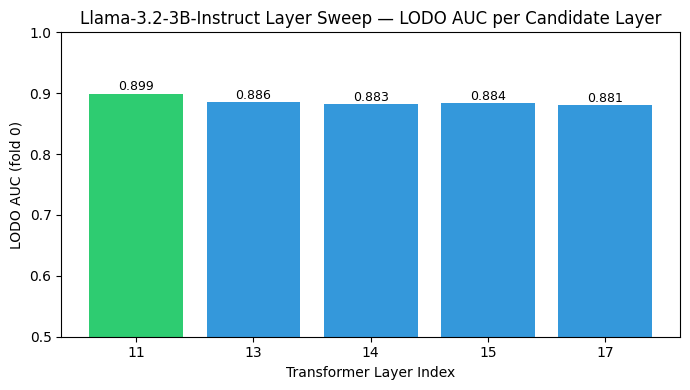

Layer sweep complete. Proceeding to full activation extraction in Section 3.


In [11]:
# Save sweep results to Drive before proceeding to full extraction
sweep_payload = {
    "held_out_fold":  first_fold_key,
    "sweep_layers":   SWEEP_LAYERS,
    "layer_auc":      {str(k): v for k, v in sweep_results.items()},
    "optimal_layer":  optimal_layer,
    "optimal_auc":    sweep_results[optimal_layer],
}
with open(LAYER_SWEEP_PATH, "w") as f:
    json.dump(sweep_payload, f, indent=2)
print(f"layer_sweep_results.json saved to {LAYER_SWEEP_PATH}")

# Bar chart
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#2ecc71" if l == optimal_layer else "#3498db" for l in SWEEP_LAYERS]
ax.bar([str(l) for l in SWEEP_LAYERS], [sweep_results[l] for l in SWEEP_LAYERS], color=colors)
ax.set_xlabel("Transformer Layer Index")
ax.set_ylabel("LODO AUC (fold 0)")
ax.set_title("Llama-3.2-3B-Instruct Layer Sweep — LODO AUC per Candidate Layer")
ax.set_ylim(0.5, 1.0)
for i, layer in enumerate(SWEEP_LAYERS):
    ax.text(i, sweep_results[layer] + 0.005, f"{sweep_results[layer]:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(f"{DRIVE_ROOT}/layer_sweep_chart.png", dpi=120)
plt.show()
print("Layer sweep complete. Proceeding to full activation extraction in Section 3.")

### Layer Sweep Interpretation

The bar chart above shows LODO AUC for each candidate layer on the held-out `first_fold_key` fold. The optimal layer (green bar) produces the highest discrimination between malicious and benign prompts when a linear probe is fitted on the frozen Llama-3.2-3B-Instruct representations.

Middle-layer activations are preferred over early layers (which encode surface-level lexical features) and late layers (which are tuned for next-token prediction and less discriminative for binary classification). The selected layer's representations are used for all samples in Section 3.

## Section 3: Full-Corpus Activation Extraction

Having identified the optimal Llama-3.2-3B-Instruct layer in Section 2, we now extract mean-pooled activations at that layer for all corpus samples. The extraction loop processes the corpus in batches of 500 samples, saving a checkpoint `.npz` file after each batch to `DRIVE_ROOT/checkpoints/`. This checkpointing strategy provides resilience against Colab session interruption — a common occurrence with long GPU jobs.

**Checkpoint resume protocol:** On session start, the resume cell scans the checkpoint directory for existing `activations_checkpoint_*.npz` files. If files exist, the highest completed batch index is identified, all cached arrays are loaded, and extraction begins from the next unprocessed batch. This makes the extraction loop fully idempotent.

**Batch size considerations:** The extraction function uses `batch_size=8` forward passes through Llama-3.2-3B-Instruct. With `output_hidden_states=True` at float16, a single forward pass with batch_size=8 and max_length=512 uses approximately 4–5 GB of additional VRAM beyond the model weights. This leaves sufficient headroom on a T4 (15.6 GB total). If a CUDA out-of-memory error occurs, the batch_size is halved automatically via the try/except block in the extraction helper.

In [12]:
def find_highest_checkpoint(prefix):
    """Return (resume_from_batch, list_of_checkpoint_paths) or (0, []) if no checkpoints exist."""
    pattern = os.path.join(CHECKPOINT_DIR, f"{prefix}_checkpoint_*.npz")
    files   = sorted(glob.glob(pattern))
    if not files:
        return 0, []
    indices = []
    for f in files:
        basename = os.path.basename(f)
        idx_str  = basename.replace(f"{prefix}_checkpoint_", "").replace(".npz", "")
        indices.append(int(idx_str))
    highest = max(indices)
    return highest + 1, sorted(files)

resume_from, existing_checkpoints = find_highest_checkpoint("activations")

cached_arrays = []
cached_ids    = []
for ckpt_path in existing_checkpoints:
    data = np.load(ckpt_path)
    cached_arrays.append(data["features"])
    cached_ids.append(data["sample_ids"])

cached_count = sum(len(a) for a in cached_arrays)
print(f"Checkpoint resume: {cached_count} samples loaded from {len(existing_checkpoints)} checkpoints")
print(f"Resuming extraction from batch {resume_from}")

Checkpoint resume: 0 samples loaded from 0 checkpoints
Resuming extraction from batch 0


In [13]:
EXTRACTION_BATCH_SIZE   = 500   # checkpoint granularity (samples per checkpoint file)
LLAMA_BATCH_SIZE        = 8     # GPU forward pass batch size (tune if OOM)
total_batches           = (N + EXTRACTION_BATCH_SIZE - 1) // EXTRACTION_BATCH_SIZE

new_arrays = []
new_ids    = []

for batch_num in range(resume_from, total_batches):
    start = batch_num * EXTRACTION_BATCH_SIZE
    end   = min(start + EXTRACTION_BATCH_SIZE, N)
    batch_texts = df["text"].iloc[start:end].tolist()

    vecs = extract_layer_activations(batch_texts, optimal_layer, batch_size=LLAMA_BATCH_SIZE)
    ids  = np.arange(start, end)

    ckpt_path = os.path.join(CHECKPOINT_DIR, f"activations_checkpoint_{batch_num}.npz")
    np.savez_compressed(ckpt_path, features=vecs, sample_ids=ids)

    new_arrays.append(vecs)
    new_ids.append(ids)
    print(f"  Batch {batch_num}/{total_batches - 1}: samples {start}–{end - 1} saved to {ckpt_path}")

print(f"\nExtraction complete: {total_batches} batches processed ({N} samples total)")

  Batch 0/104: samples 0–499 saved to /content/drive/MyDrive/PromptGuard/checkpoints/activations_checkpoint_0.npz
  Batch 1/104: samples 500–999 saved to /content/drive/MyDrive/PromptGuard/checkpoints/activations_checkpoint_1.npz
  Batch 2/104: samples 1000–1499 saved to /content/drive/MyDrive/PromptGuard/checkpoints/activations_checkpoint_2.npz
  Batch 3/104: samples 1500–1999 saved to /content/drive/MyDrive/PromptGuard/checkpoints/activations_checkpoint_3.npz
  Batch 4/104: samples 2000–2499 saved to /content/drive/MyDrive/PromptGuard/checkpoints/activations_checkpoint_4.npz
  Batch 5/104: samples 2500–2999 saved to /content/drive/MyDrive/PromptGuard/checkpoints/activations_checkpoint_5.npz
  Batch 6/104: samples 3000–3499 saved to /content/drive/MyDrive/PromptGuard/checkpoints/activations_checkpoint_6.npz
  Batch 7/104: samples 3500–3999 saved to /content/drive/MyDrive/PromptGuard/checkpoints/activations_checkpoint_7.npz
  Batch 8/104: samples 4000–4499 saved to /content/drive/MyDri

In [14]:
# Assemble final array from all checkpoints (cached + newly extracted)
all_features   = np.concatenate(cached_arrays + new_arrays, axis=0)
all_sample_ids = np.concatenate(cached_ids    + new_ids,    axis=0)

assert all_features.shape == (N, 3072), \
    f"Shape mismatch: expected ({N}, 3072), got {all_features.shape}"
assert len(all_sample_ids) == N, \
    f"sample_ids length mismatch: expected {N}, got {len(all_sample_ids)}"
assert np.array_equal(all_sample_ids, np.arange(N)), \
    "sample_ids are not sequential 0..N-1 — check for checkpoint gaps"

np.savez_compressed(ACTIVATION_PATH, features=all_features, sample_ids=all_sample_ids)
print(f"activation_features.npz saved: shape={all_features.shape}, path={ACTIVATION_PATH}")

activation_features.npz saved: shape=(52381, 3072), path=/content/drive/MyDrive/PromptGuard/activation_features.npz


In [15]:
# Spot-check: shape, NaN/Inf, row count
act = np.load(ACTIVATION_PATH)
features   = act["features"]
sample_ids = act["sample_ids"]

print(f"Shape:       {features.shape}  (expected ({N}, 3072))")
print(f"Dtype:       {features.dtype}")
print(f"NaN count:   {np.isnan(features).sum()}")
print(f"Inf count:   {np.isinf(features).sum()}")
print(f"Min value:   {features.min():.4f}")
print(f"Max value:   {features.max():.4f}")
print(f"Mean L2 norm per sample: {np.linalg.norm(features, axis=1).mean():.4f}")
print(f"Sample IDs:  {sample_ids[0]}..{sample_ids[-1]} (expected 0..{N - 1})")

assert features.shape == (N, 3072),     "Shape check FAILED"
assert np.isnan(features).sum() == 0,   "NaN values detected — extraction error"
assert np.isinf(features).sum() == 0,   "Inf values detected — extraction error"
assert len(sample_ids) == N,            "sample_ids length mismatch"
print("\nSpot-check PASSED: no NaN, no Inf, correct shape and sample count")

Shape:       (52381, 3072)  (expected (52381, 3072))
Dtype:       float32
NaN count:   0
Inf count:   0
Min value:   -193.5494
Max value:   210.3608
Mean L2 norm per sample: 47.5421
Sample IDs:  0..52380 (expected 0..52380)

Spot-check PASSED: no NaN, no Inf, correct shape and sample count


In [16]:
# Free Llama model from VRAM before CPU-heavy sections
del model
del tokenizer
torch.cuda.empty_cache()
vram_free = (torch.cuda.get_device_properties(0).total_memory
             - torch.cuda.memory_allocated(0)) / 1e9
print(f"Llama model freed. VRAM available: {vram_free:.1f} GB")
print("Proceeding to Section 4 (Heuristic Feature Extraction — CPU only)")

Llama model freed. VRAM available: 36.8 GB
Proceeding to Section 4 (Heuristic Feature Extraction — CPU only)


## Section 4: Heuristic Rule-Based Feature Extraction

Heuristic features provide a lightweight, interpretable feature channel that complements the high-dimensional activation vectors and dense sentence embeddings. Each feature targets a distinct surface-level signal known from prompt injection literature and deployed detection systems. The feature set is designed to be:

1. **Fast to compute** — Pure Python regex and string operations; no GPU or large model required
2. **Interpretable** — Each feature has a clear semantic meaning, making the probe model partially auditable
3. **Leakage-free** — The length z-score is computed against the benign-only subset (label=0) of the corpus; no per-fold statistics are required because this is a scaling feature, not a learned transformation

**Feature definitions:**

| Feature | Type | Description |
|---------|------|-------------|
| `phrase_count` | int | Count of known injection override phrases (curated list of 30 patterns) |
| `has_base64` | 0/1 | Regex match for base64-encoded block ≥20 chars |
| `has_homoglyph` | 0/1 | Detects Cyrillic, Greek, or fullwidth Latin characters mixed with ASCII |
| `has_zero_width` | 0/1 | Detects zero-width space/joiner/ZWNBSP Unicode characters |
| `has_role_tag` | 0/1 | XML/JSON role tags: `<system>`, `[INST]`, `"role":`, etc. |
| `has_separator` | 0/1 | Horizontal rule separators used as prompt boundary markers |
| `imperative_verb_ratio` | float | Fraction of sentences whose first word is a known imperative verb |
| `length_zscore` | float | Token count z-score relative to benign-only corpus mean/std |

**Implementation note:** Imperative verb detection uses a curated ~50-verb list rather than spaCy POS tagging. This avoids a pip install + model download in Colab while providing adequate signal for a heuristic feature. The limitation (only known verbs detected; novel imperative verbs missed) is explicitly noted as a research caveat.


In [17]:
# Instruction-override phrases — curated from academic prompt injection literature
# (Perez & Ribeiro 2022; Greshake et al. 2023; Liu et al. 2023)
OVERRIDE_PHRASES = [
    "ignore previous instructions",
    "ignore all previous",
    "ignore the above",
    "disregard your",
    "disregard all previous",
    "disregard the above",
    "forget previous instructions",
    "forget all previous",
    "forget your training",
    "you are now",
    "new persona",
    "system prompt override",
    "override your instructions",
    "ignore your instructions",
    "do not follow",
    "act as if",
    "pretend you are",
    "act as a",
    "your new instructions",
    "from now on you",
    "your previous instructions",
    "[system]",
    "---new instructions---",
    "your instructions are void",
    "bypass your",
    "disregard safety",
    "ignore ethics",
    "your actual instructions",
    "developer mode enabled",
    "dan mode",
]

BASE64_RE    = re.compile(r'[A-Za-z0-9+/]{20,}={0,2}')
ZERO_WIDTH_RE = re.compile(r'[\u200b\u200c\u200d\ufeff\u2060]')
ROLE_TAG_RE  = re.compile(
    r'<(system|user|assistant|human|ai)>|\[INST\]|"role"\s*:', re.IGNORECASE
)
SEPARATOR_RE = re.compile(r'(---+|===+|\*\*\*+|####+)')

IMPERATIVE_VERBS = {
    "ignore", "disregard", "forget", "override", "bypass", "act", "pretend",
    "assume", "behave", "roleplay", "write", "produce", "generate", "output",
    "print", "tell", "reveal", "expose", "show", "provide", "give", "list",
    "say", "repeat", "translate", "send", "execute", "run", "do", "make",
    "create", "respond", "reply", "answer", "follow", "obey", "comply",
    "enable", "disable", "enter", "exit", "switch", "change", "become",
    "stop", "start", "continue", "complete", "finish",
}

def has_homoglyph(text):
    """Detect Cyrillic, Greek, or fullwidth Latin chars mixed with ASCII."""
    for ch in text:
        cp = ord(ch)
        cat = unicodedata.category(ch)
        if cat in ('Ll', 'Lu', 'Lt', 'Lm', 'Lo'):
            if (0x0400 <= cp <= 0x04FF or   # Cyrillic
                0x0370 <= cp <= 0x03FF or   # Greek
                0xFF01 <= cp <= 0xFF60):    # Fullwidth Latin
                return 1
    return 0

def imperative_verb_ratio(text):
    """Fraction of sentences whose first word is a known imperative verb."""
    sentences = re.split(r'[.!?;]\s+', text.strip())
    if not sentences:
        return 0.0
    hits = sum(
        1 for sent in sentences
        if sent.strip().split() and sent.strip().split()[0].lower() in IMPERATIVE_VERBS
    )
    return hits / len(sentences)

def extract_heuristics(text):
    """Return dict of heuristic features for a single text. token_len is a helper for z-score."""
    text_lower = text.lower()
    return {
        "phrase_count":          sum(1 for p in OVERRIDE_PHRASES if p in text_lower),
        "has_base64":            int(bool(BASE64_RE.search(text))),
        "has_homoglyph":         has_homoglyph(text),
        "has_zero_width":        int(bool(ZERO_WIDTH_RE.search(text))),
        "has_role_tag":          int(bool(ROLE_TAG_RE.search(text))),
        "has_separator":         int(bool(SEPARATOR_RE.search(text))),
        "imperative_verb_ratio": imperative_verb_ratio(text),
        "token_len":             len(text.split()),   # helper for z-score, dropped before save
    }

print(f"Heuristic feature definitions loaded: {len(OVERRIDE_PHRASES)} override phrases, "
      f"{len(IMPERATIVE_VERBS)} imperative verbs")


Heuristic feature definitions loaded: 30 override phrases, 49 imperative verbs


In [18]:
print(f"Extracting heuristic features for {N} samples (CPU, single pass)...")
rows = [extract_heuristics(text) for text in df["text"]]
heuristic_df = pd.DataFrame(rows)

# Length z-score: computed against benign-only subset to avoid leakage
# (benign samples = label 0; mean and std computed once on full corpus benign subset)
benign_lens  = heuristic_df.loc[df["label"] == 0, "token_len"].values
benign_mean  = float(benign_lens.mean())
benign_std   = float(benign_lens.std())
heuristic_df["length_zscore"] = (
    (heuristic_df["token_len"] - benign_mean) / max(benign_std, 1e-9)
)

# Drop raw token_len helper column — not a feature, used only for z-score
heuristic_df = heuristic_df.drop(columns=["token_len"])

# Validate shape and columns
EXPECTED_COLS = [
    "phrase_count", "has_base64", "has_homoglyph", "has_zero_width",
    "has_role_tag", "has_separator", "imperative_verb_ratio", "length_zscore",
]
assert list(heuristic_df.columns) == EXPECTED_COLS, \
    f"Column mismatch: {list(heuristic_df.columns)} != {EXPECTED_COLS}"
assert len(heuristic_df) == N, f"Row count mismatch: {len(heuristic_df)} != {N}"
assert heuristic_df.isnull().sum().sum() == 0, "Null values found in heuristic features"

print(f"Heuristic features extracted: shape={heuristic_df.shape}")
print(f"Length z-score: benign mean={benign_mean:.1f} tokens, std={benign_std:.1f}")
print(f"\nFeature stats:")
print(heuristic_df.describe().round(4))


Extracting heuristic features for 52381 samples (CPU, single pass)...
Heuristic features extracted: shape=(52381, 8)
Length z-score: benign mean=35.7 tokens, std=96.5

Feature stats:
       phrase_count  has_base64  has_homoglyph  has_zero_width  has_role_tag  \
count    52381.0000  52381.0000     52381.0000      52381.0000    52381.0000   
mean         0.0280      0.0181         0.0017          0.0009        0.0073   
std          0.1741      0.1332         0.0414          0.0296        0.0853   
min          0.0000      0.0000         0.0000          0.0000        0.0000   
25%          0.0000      0.0000         0.0000          0.0000        0.0000   
50%          0.0000      0.0000         0.0000          0.0000        0.0000   
75%          0.0000      0.0000         0.0000          0.0000        0.0000   
max          3.0000      1.0000         1.0000          1.0000        1.0000   

       has_separator  imperative_verb_ratio  length_zscore  
count     52381.0000             52

In [19]:
# Save with index=False to prevent unnamed index column in CSV
heuristic_df.to_csv(HEURISTIC_PATH, index=False)
print(f"heuristic_features.csv saved: path={HEURISTIC_PATH}")

# Validate round-trip
heu_check = pd.read_csv(HEURISTIC_PATH)
assert heu_check.shape == (N, 8), \
    f"Round-trip shape mismatch: {heu_check.shape} != ({N}, 8)"
assert list(heu_check.columns) == EXPECTED_COLS, \
    f"Round-trip column mismatch: {list(heu_check.columns)}"
print(f"Round-trip validation PASSED: shape={heu_check.shape}, columns={list(heu_check.columns)}")

# Class-conditional summary to verify features have signal
for col in ["phrase_count", "has_base64", "has_zero_width", "has_role_tag", "imperative_verb_ratio"]:
    malicious_mean = heuristic_df.loc[df["label"] == 1, col].mean()
    benign_mean_col = heuristic_df.loc[df["label"] == 0, col].mean()
    print(f"  {col}: malicious_mean={malicious_mean:.4f}, benign_mean={benign_mean_col:.4f}")


heuristic_features.csv saved: path=/content/drive/MyDrive/PromptGuard/heuristic_features.csv
Round-trip validation PASSED: shape=(52381, 8), columns=['phrase_count', 'has_base64', 'has_homoglyph', 'has_zero_width', 'has_role_tag', 'has_separator', 'imperative_verb_ratio', 'length_zscore']
  phrase_count: malicious_mean=0.0392, benign_mean=0.0061
  has_base64: malicious_mean=0.0173, benign_mean=0.0195
  has_zero_width: malicious_mean=0.0012, benign_mean=0.0003
  has_role_tag: malicious_mean=0.0110, benign_mean=0.0001
  imperative_verb_ratio: malicious_mean=0.3035, benign_mean=0.0798


## Section 5: Sentence Embedding Extraction

Sentence embeddings provide a dense semantic feature channel that captures meaning independent of surface-level lexical patterns. We use `sentence-transformers/all-mpnet-base-v2`, a widely-used model fine-tuned for semantic similarity tasks. Unlike the Llama activation probe, this channel operates entirely on CPU and produces 768-dimensional vectors.

The all-mpnet-base-v2 model is appropriate for this task because:
- It is fine-tuned specifically for semantic similarity (vs next-token prediction)
- It handles truncation and padding internally
- It produces consistent, normalised embeddings suitable for downstream logistic regression

**Checkpoint resume:** The embedding extraction resumes from an existing partial `embedding_features.npz` if the file exists on Drive. This handles Colab session interruption during the ~15–30 minute CPU encode job. The resume point is determined by the length of `sample_ids` in the existing file.

**Batch size:** 64 samples per encode call. `SentenceTransformer.encode()` handles the internal batching loop and shows a progress bar.


In [20]:
model_emb = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")
print(f"SentenceTransformer loaded: all-mpnet-base-v2")

# Checkpoint resume: if embedding_features.npz already exists, resume from saved count
if os.path.exists(EMBEDDING_PATH):
    existing_emb      = np.load(EMBEDDING_PATH)
    resume_from_emb   = len(existing_emb["sample_ids"])
    cached_emb        = [existing_emb["features"]]
    cached_emb_ids    = [existing_emb["sample_ids"]]
    print(f"Resuming embedding extraction from sample {resume_from_emb} ({resume_from_emb}/{N})")
else:
    resume_from_emb = 0
    cached_emb      = []
    cached_emb_ids  = []
    print(f"No existing embedding checkpoint. Extracting all {N} samples.")

texts_remaining = df["text"].iloc[resume_from_emb:].tolist()

if texts_remaining:
    print(f"Encoding {len(texts_remaining)} remaining samples (batch_size=64)...")
    new_embeddings = model_emb.encode(
        texts_remaining,
        batch_size=64,
        show_progress_bar=True,
        convert_to_numpy=True,
    )
    cached_emb.append(new_embeddings)
    cached_emb_ids.append(np.arange(resume_from_emb, N))
else:
    print("All samples already cached. Assembling from checkpoint.")

all_embeddings = np.concatenate(cached_emb, axis=0)
all_emb_ids    = np.concatenate(cached_emb_ids, axis=0)

assert all_embeddings.shape == (N, 768), \
    f"Shape mismatch: expected ({N}, 768), got {all_embeddings.shape}"
assert len(all_emb_ids) == N, \
    f"sample_ids length mismatch: expected {N}, got {len(all_emb_ids)}"

np.savez_compressed(EMBEDDING_PATH, features=all_embeddings, sample_ids=all_emb_ids)
print(f"\nembedding_features.npz saved: shape={all_embeddings.shape}, path={EMBEDDING_PATH}")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

SentenceTransformer loaded: all-mpnet-base-v2
No existing embedding checkpoint. Extracting all 52381 samples.
Encoding 52381 remaining samples (batch_size=64)...


Batches:   0%|          | 0/819 [00:00<?, ?it/s]


embedding_features.npz saved: shape=(52381, 768), path=/content/drive/MyDrive/PromptGuard/embedding_features.npz


In [21]:
emb_check = np.load(EMBEDDING_PATH)
emb_feats = emb_check["features"]
emb_ids   = emb_check["sample_ids"]

print(f"Shape:     {emb_feats.shape}  (expected ({N}, 768))")
print(f"Row count: {len(emb_feats)} (corpus size: {N})")
print(f"NaN count: {np.isnan(emb_feats).sum()}")
print(f"Inf count: {np.isinf(emb_feats).sum()}")

assert emb_feats.shape == (N, 768),       "Shape check FAILED"
assert len(emb_feats) == N,               "Row count does not match corpus"
assert np.isnan(emb_feats).sum() == 0,    "NaN values detected"
assert np.isinf(emb_feats).sum() == 0,    "Inf values detected"

print(f"Verification PASSED: shape={emb_feats.shape}, no NaN, no Inf, row count matches corpus")


Shape:     (52381, 768)  (expected (52381, 768))
Row count: 52381 (corpus size: 52381)
NaN count: 0
Inf count: 0
Verification PASSED: shape=(52381, 768), no NaN, no Inf, row count matches corpus


## Section 6: Phase 3 Completion Summary

This section validates that all required Phase 3 artifacts exist on Google Drive and prints a structured status report. This mirrors the completion summary pattern from NB01 and NB02.

**Required artifacts:**

| Artifact | Description | Consumer |
|----------|-------------|----------|
| `activation_features.npz` | Llama-3.2-3B-Instruct activations at optimal layer, shape (N, 3072) | Phase 4: Probe training |
| `heuristic_features.csv` | 8-column rule-based features, shape (N, 8) | Phase 4: Ensemble heuristic channel |
| `embedding_features.npz` | all-mpnet-base-v2 embeddings, shape (N, 768) | Phase 4: Embedding channel |
| `lodo_splits.json` | Validated 15-fold LODO definitions | Phase 4: Training splits; Phase 5: Evaluation |
| `layer_sweep_results.json` | Per-layer LODO AUC and optimal layer | Phase 4: Documentation; Phase 6: Audit |


In [22]:
import os, json
import numpy as np
import pandas as pd

print("=" * 65)
print("PHASE 3: FEATURE EXTRACTION — COMPLETION SUMMARY")
print("=" * 65)

artifacts = {
    "activation_features.npz":  ACTIVATION_PATH,
    "heuristic_features.csv":   HEURISTIC_PATH,
    "embedding_features.npz":   EMBEDDING_PATH,
    "lodo_splits.json":         LODO_SPLITS_PATH,
    "layer_sweep_results.json": LAYER_SWEEP_PATH,
}

all_ok = True
for name, path in artifacts.items():
    exists = os.path.exists(path)
    status = "OK" if exists else "WARN"
    if not exists:
        all_ok = False
    print(f"  [{status}] {name}")
    print(f"         {path}")

print()
print("Shape verification:")

# activation_features.npz
act = np.load(ACTIVATION_PATH)
act_shape = act["features"].shape
act_ok = act_shape == (N, 3072) and np.isnan(act["features"]).sum() == 0
print(f"  [{'OK' if act_ok else 'WARN'}] activation_features: shape={act_shape}  "
      f"NaN={np.isnan(act['features']).sum()}")

# embedding_features.npz
emb = np.load(EMBEDDING_PATH)
emb_shape = emb["features"].shape
emb_ok = emb_shape == (N, 768) and np.isnan(emb["features"]).sum() == 0
print(f"  [{'OK' if emb_ok else 'WARN'}] embedding_features:  shape={emb_shape}  "
      f"NaN={np.isnan(emb['features']).sum()}")

# heuristic_features.csv
heu = pd.read_csv(HEURISTIC_PATH)
heu_ok = heu.shape == (N, 8) and heu.isnull().sum().sum() == 0
print(f"  [{'OK' if heu_ok else 'WARN'}] heuristic_features:  shape={heu.shape}  "
      f"nulls={heu.isnull().sum().sum()}")

# lodo_splits.json
with open(LODO_SPLITS_PATH) as f:
    splits = json.load(f)
splits_ok = len(splits) == 15
print(f"  [{'OK' if splits_ok else 'WARN'}] lodo_splits:         folds={len(splits)} (expected 15)")

# layer_sweep_results.json
with open(LAYER_SWEEP_PATH) as f:
    sweep = json.load(f)
sweep_ok = "optimal_layer" in sweep
print(f"  [{'OK' if sweep_ok else 'WARN'}] layer_sweep:         optimal_layer={sweep.get('optimal_layer')}  "
      f"AUC={sweep.get('optimal_auc', 0):.4f}")

print()
print("=" * 65)
if all_ok and act_ok and emb_ok and heu_ok and splits_ok and sweep_ok:
    print("PHASE 3 COMPLETE — All artifacts validated.")
    print("Ready for Phase 4: Ensemble Training (NB04)")
    print("Phase 4 reads: activation_features.npz, heuristic_features.csv,")
    print("               embedding_features.npz, lodo_splits.json")
else:
    print("PHASE 3 INCOMPLETE — One or more artifacts missing or invalid.")
    print("Review [WARN] items above before proceeding to Phase 4.")
print("=" * 65)


PHASE 3: FEATURE EXTRACTION — COMPLETION SUMMARY
  [OK] activation_features.npz
         /content/drive/MyDrive/PromptGuard/activation_features.npz
  [OK] heuristic_features.csv
         /content/drive/MyDrive/PromptGuard/heuristic_features.csv
  [OK] embedding_features.npz
         /content/drive/MyDrive/PromptGuard/embedding_features.npz
  [OK] lodo_splits.json
         /content/drive/MyDrive/PromptGuard/lodo_splits.json
  [OK] layer_sweep_results.json
         /content/drive/MyDrive/PromptGuard/layer_sweep_results.json

Shape verification:
  [OK] activation_features: shape=(52381, 3072)  NaN=0
  [OK] embedding_features:  shape=(52381, 768)  NaN=0
  [OK] heuristic_features:  shape=(52381, 8)  nulls=0
  [OK] lodo_splits:         folds=15 (expected 15)
  [OK] layer_sweep:         optimal_layer=11  AUC=0.8995

PHASE 3 COMPLETE — All artifacts validated.
Ready for Phase 4: Ensemble Training (NB04)
Phase 4 reads: activation_features.npz, heuristic_features.csv,
               embedding_fe